In [ ]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [ ]:
# NYC Open Data Collisions API
api = 'https://data.cityofnewyork.us/resource/h9gi-nx95.json'

In [ ]:
# request & check response
r = requests.get(api)
r

<Response [200]>

In [ ]:
# get json
data = r.json()

In [ ]:
# turn into dataframe
collisions = pd.DataFrame(data)

In [ ]:
# check data
collisions.head()

,crash_date,crash_time,on_street_name,off_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,...,latitude,longitude,location,contributing_factor_vehicle_3,vehicle_type_code_3,cross_street_name,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5
0,2021-09-11T00:00:00.000,2:39,WHITESTONE EXPRESSWAY,20 AVENUE,2,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-03-26T00:00:00.000,11:45,QUEENSBORO BRIDGE UPPER,NaN,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-11-01T00:00:00.000,1:29,OCEAN PARKWAY,AVENUE K,1,0,0,0,0,0,...,40.62179,-73.970024,"{'latitude': '40.62179', 'longitude': '-73.970...",Unspecified,Sedan,NaN,NaN,NaN,NaN,NaN
3,2022-06-29T00:00:00.000,6:55,THROGS NECK BRIDGE,NaN,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-09-21T00:00:00.000,13:21,BROOKLYN BRIDGE,NaN,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# check info
collisions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   crash_date                     1000 non-null   object
 1   crash_time                     1000 non-null   object
 2   on_street_name                 742 non-null    object
 3   off_street_name                450 non-null    object
 4   number_of_persons_injured      1000 non-null   object
 5   number_of_persons_killed       1000 non-null   object
 6   number_of_pedestrians_injured  1000 non-null   object
 7   number_of_pedestrians_killed   1000 non-null   object
 8   number_of_cyclist_injured      1000 non-null   object
 9   number_of_cyclist_killed       1000 non-null   object
 10  number_of_motorist_injured     1000 non-null   object
 11  number_of_motorist_killed      1000 non-null   object
 12  contributing_factor_vehicle_1  997 non-null    object
 13  cont

In [ ]:
# change crash date column to datetime
collisions['crash_date'] = pd.to_datetime(collisions['crash_date'])

In [ ]:
# extract year, month and day of week into separate columns
collisions['YEAR'] = collisions['crash_date'].dt.year
collisions['MONTH'] = collisions['crash_date'].dt.month
collisions['DAY_OF_WEEK'] = collisions['crash_date'].dt.day_of_week

In [ ]:
# change crash time column to datetime
collisions['crash_time'] = pd.to_datetime(collisions['crash_time'], format='%H:%M')

In [ ]:
# extract hour
collisions['HOUR'] = collisions['crash_time'].dt.hour

In [ ]:
# change datatype of lat & long columns into floats
collisions['latitude'] = collisions['latitude'].astype(float)
collisions['longitude'] = collisions['longitude'].astype(float)

In [ ]:
# change dataype of following columns to floats
collisions['number_of_persons_injured'] = collisions['number_of_persons_injured'].astype(float)
collisions['number_of_persons_killed'] = collisions['number_of_persons_killed'].astype(float)

## Reverse Geocoding to get Borough

In [ ]:
# token for geocoding
token = 'pk.eyJ1IjoianVuamloaSIsImEiOiJjbW91a29sZXQwYWtxMnJweDl4eW44ZDBuIn0.oFkxnIAGn-NodIU4FFKCHw'

In [ ]:
# function to find the borough from lat, long
def borough(lat, long):
  # if lat or long are missing, return nan
  if pd.isna(lat) or pd.isna(long) or (lat==0) or (long==0):
    return np.nan
  else:
    # mapbox api
    url = f'https://api.mapbox.com/search/geocode/v6/reverse?longitude={long}&latitude={lat}&access_token={token}&types=locality'
    # response & json
    response = requests.get(url)
    data = response.json()
    # if results are empty
    if data['features'] == []:
      return np.nan
    else:
      # find borough name
      b = data['features'][0]['properties']['name']
      return b

In [ ]:
# a new borough column
collisions['BOROUGH'] = collisions.apply(lambda x: borough(x['latitude'], x['longitude']), axis=1)

In [ ]:
# fill in missing boroughs with old borough column
collisions['BOROUGH'] = np.where(collisions['BOROUGH'].isna(), collisions['borough'], collisions['BOROUGH'])

In [ ]:
# make all values capitalized to make them consistent
collisions['BOROUGH'] = collisions['BOROUGH'].str.title()

## Data Exploration

In [ ]:
# create a column for whether injured / killed == 0 or 1
collisions['injured'] = np.where(collisions['number_of_persons_injured'] > 0, 1, 0)
collisions['killed'] = np.where(collisions['number_of_persons_killed'] > 0, 1, 0)

Text(0.5, 1.0, 'Number of Persons Injured by Borough')

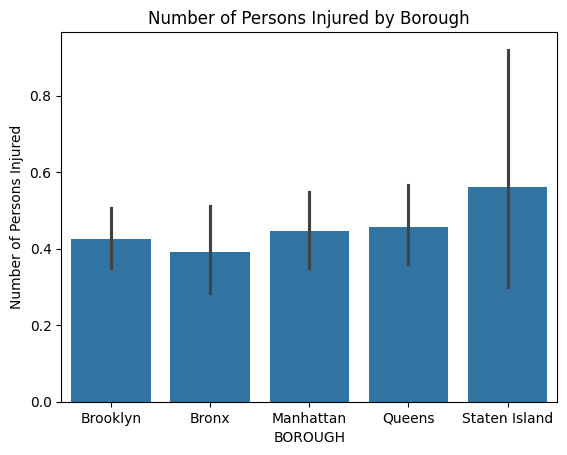

In [ ]:
# borough vs. number of persons injured
sns.barplot(data=collisions, x='BOROUGH', y='number_of_persons_injured')
plt.ylabel('Number of Persons Injured')
plt.title('Number of Persons Injured by Borough')

Text(0.5, 1.0, 'Number of Persons Injured by Hour')

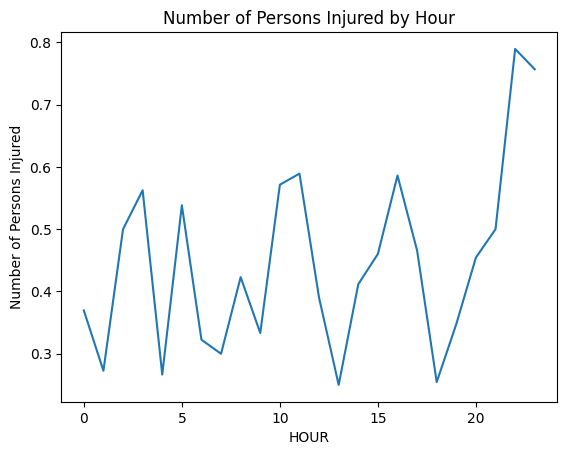

In [ ]:
# hour vs. number of persons injured
sns.lineplot(data=collisions, x='HOUR', y='number_of_persons_injured', errorbar=None)
plt.ylabel('Number of Persons Injured')
plt.title('Number of Persons Injured by Hour')

The Number of Persons Injured by Borough graph reveals that Staten Island has the highest average injury rate per crash at approximately 0.56, though the wide error bars suggest significant variability or a smaller sample size compared to the Bronx, which maintains the lowest average at roughly 0.39. This geographic data is complemented by the Number of Persons Injured by Hour line chart, which highlights a dramatic spike in crash severity late at night, specifically peaking at hour 22 with nearly 0.8 persons injured per incident. While secondary peaks occur during the early morning (hour 5) and mid-afternoon (hour 16), the sharp rise at night—contrasted with low points at hours 1, 13, and 18—suggests that while nighttime collisions may be less frequent, they are statistically much more likely to result in injuries. Together, these trends indicate that both location and specific high-risk time windows, particularly late-night hours, will be crucial features for our logistic regression model.

In [ ]:
# copy dataframe
collisions_map = collisions.copy()
# drop where long/lat = 0 or null
collisions_map.drop(collisions_map[collisions_map['longitude'] == 0].index, inplace=True)
collisions_map.drop(collisions_map[collisions_map['latitude'] == 0].index, inplace=True)
collisions_map.dropna(subset=['longitude', 'latitude'], inplace=True)
# calculate injury rate
collisions_map['injury_rate'] = collisions_map['number_of_persons_injured'] / collisions_map['number_of_persons_injured'].sum()

Text(0, 0.5, 'Latitude')

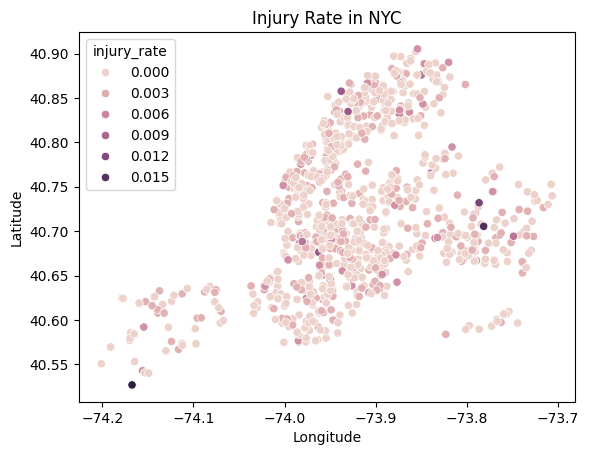

In [ ]:
# map NYC with respect to injury rate
sns.scatterplot(data=collisions_map, x='longitude', y='latitude', hue='injury_rate')
plt.title('Injury Rate in NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

This scatterplot maps traffic collisions across New York City, using color intensity to highlight injury rate at each coordinate. While the vast majority of incidents are minor (represented by the lighter clusters), the sparse distribution of dark purple dots identifies high-impact "hotspots" where crashes resulted in significant harm. Geographically, the heavy concentration of points across the boroughs illustrates how urban density and traffic volume serve as primary drivers for collision frequency.

In [ ]:
# group by contributing factor and calculate the injury rate
collisions.groupby('contributing_factor_vehicle_1')['injured'].mean().sort_values(ascending=False)

,injured
contributing_factor_vehicle_1,
Passenger Distraction,1.000000
Pavement Defective,1.000000
Lost Consciousness,1.000000
Drugs (illegal),1.000000
Tinted Windows,1.000000
Pedestrian/Bicyclist/Other Pedestrian Error/Confusion,0.666667
Brakes Defective,0.666667
Failure to Yield Right-of-Way,0.611940
Traffic Control Disregarded,0.562500


In [ ]:
# turn into dataframe
factors_injury_rate = pd.DataFrame(collisions.groupby('contributing_factor_vehicle_1')['injured'].mean().sort_values(ascending=False))
# only take the top 10 factors
factors_injury_rate = factors_injury_rate.head(10)
# rename
factors_injury_rate.rename(index={'Pedestrian/Bicyclist/Other Pedestrian Error/Confusion': 'Pedestrian Confusion'}, inplace=True)

Text(0.5, 0, 'Injury Rate')

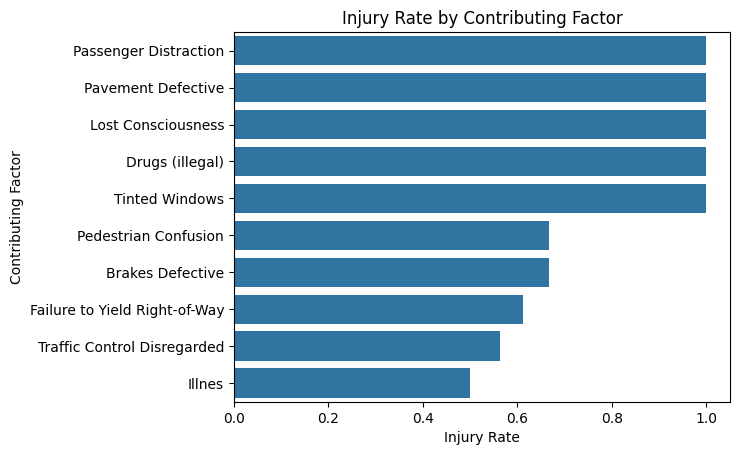

In [ ]:
# plot injury rate by contributing factor
sns.barplot(data=factors_injury_rate, y=factors_injury_rate.index, x='injured')
plt.title('Injury Rate by Contributing Factor')
plt.ylabel('Contributing Factor')
plt.xlabel('Injury Rate')

## Logistic Regression Modeling for Injured (Yes/No)
We are predicting whether a NYC motor vehicle crash results in an injury using logistic regression.

In [ ]:
# make a final dataframe with only the columns needed
final_collisions = pd.DataFrame({'YEAR': collisions['YEAR'],
                                 'MONTH': collisions['MONTH'],
                                 'DAY_OF_WEEK': collisions['DAY_OF_WEEK'],
                                 'HOUR': collisions['HOUR'],
                                 'FACTORS': collisions['contributing_factor_vehicle_1'],
                                 'VEHICLE_CODE': collisions['vehicle_type_code1'],
                                 'BOROUGH': collisions['BOROUGH'],
                                 'KILLED': collisions['killed'],
                                 'INJURED': collisions['injured'],
                                 'INJURED': collisions['injured']}
                                )

In [ ]:
# instantiate transformers
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
scale = StandardScaler()
cat_impute = SimpleImputer(strategy='most_frequent')

In [ ]:
# transformer
# fill in missing values then one hot encode object columns
# one hot encode the year, month, day, and hour
# passthrough the remainder
transformer = make_column_transformer((make_pipeline(cat_impute, ohe), ['BOROUGH', 'FACTORS', 'VEHICLE_CODE'] ),
                                      (ohe, ['YEAR', 'MONTH', 'DAY_OF_WEEK', 'HOUR']),
                                      remainder='passthrough')

In [ ]:
# pipeline
pipe = Pipeline([ ('transformer', transformer),
                  ('model', LogisticRegression())
                ])

In [ ]:
# define X and y (target=injured)
X = final_collisions.drop(columns=['KILLED', 'INJURED'])
y = final_collisions['INJURED']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
# fit pipeline
pipe.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['BOROUGH', 'FACTORS',
                                                   'VEHICLE_CODE']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['YEAR', 'MONTH',
                                                   'DAY_OF_WEEK', 'HOUR'])])),
                ('model', LogisticRegression())])

In [ ]:
#examine train and test scores
print(f'Train Accuracy: {pipe.score(X_train, y_train)}')
print(f'Test Accuracy: {pipe.score(X_test, y_test)}')

Train Accuracy: 0.7293333333333333
Test Accuracy: 0.676


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
# compare with baseline score
y_train.value_counts(normalize = True)

,proportion
INJURED,
0,0.657333
1,0.342667


The logistic regression model achieves a training accuracy of 0.729 and a test accuracy of 0.676, indicating that the model generalizes well with minimal overfitting. However, the model is only slightly better than the baseline accuracy at 0.657.



Accuracy alone may be misleading and further evaluation using recall and confusion matrix is necessary to assess performance on injury prediction.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Text(0.5, 1.0, 'Confusion Matrix of Injured')

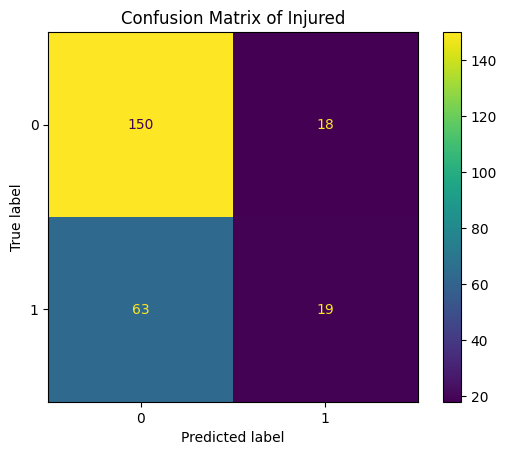

In [ ]:
# confusion matrix
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test)
plt.title('Confusion Matrix of Injured')

Recall = TP / (TP + FN)

= 19 / (19 + 63)
= 19 / 82
≈ 0.23

The model performs well at predicting non-injury crashes (TN = 149), but struggles significantly to identify injury cases (FN = 63). Recall score is only at 0.23.



In [ ]:
# interpreting coefficients
coefs = pd.DataFrame({'feature': pipe['transformer'].get_feature_names_out(),
                      'coef': pipe['model'].coef_[0]})

In [ ]:
# sort values highest to lowest
coefs.sort_values('coef', ascending=False, inplace=True)

In [ ]:
# top 10 coefs
coefs.head(10)

,feature,coef
52,pipeline__VEHICLE_CODE_Motorcycle,1.397396
38,pipeline__VEHICLE_CODE_Bike,1.203374
13,pipeline__FACTORS_Failure to Yield Right-of-Way,1.068676
98,onehotencoder__HOUR_11,0.924803
30,pipeline__FACTORS_Traffic Control Disregarded,0.886053
45,pipeline__VEHICLE_CODE_E-Bike,0.876925
110,onehotencoder__HOUR_23,0.843274
27,pipeline__FACTORS_Pedestrian/Bicyclist/Other P...,0.785330
89,onehotencoder__HOUR_2,0.610991
15,pipeline__FACTORS_Following Too Closely,0.602847


The logistic regression results show that injury likelihood is most strongly associated with both vulnerable road users and risky driving behaviors, with motorcycle involvement (β = 1.40) and bicycle involvement (β = 1.20) having the largest positive effects, indicating substantially higher odds of injury compared to baseline vehicle types. Key traffic violations also play a major role, particularly failure to yield right-of-way (β = 1.07) and disregarding traffic control signals (β = 0.90), reinforcing that rule-breaking behaviors are strong predictors of injury severity. In addition, alternative and micromobility vehicles such as e-bikes (β = 0.88) are also positively associated with injury risk, likely reflecting lower physical protection in collisions. Temporal patterns further contribute, with certain hours such as 11 AM (β = 0.92) and 11 PM (β = 0.84) showing elevated risk, suggesting that both midday activity and late-night conditions are linked to more severe crashes. Overall, the model indicates that injury outcomes are driven by a combination of road user type, traffic violations, and time-of-day effects.

In [ ]:
# create dataframe of all hours, months, days
hour_df = coefs[coefs['feature'].str.contains('HOUR_')].copy().sort_values('coef', ascending=False)
month_df = coefs[coefs['feature'].str.contains('MONTH_')].copy().sort_values('coef', ascending=False)
day_df = coefs[coefs['feature'].str.contains('DAY_OF_WEEK_')].copy().sort_values('coef', ascending=False)

In [ ]:
# see which hours lead to injuries the most
hour_df.head(5)


,feature,coef
98,onehotencoder__HOUR_11,0.924803
110,onehotencoder__HOUR_23,0.843274
89,onehotencoder__HOUR_2,0.610991
97,onehotencoder__HOUR_10,0.558938
101,onehotencoder__HOUR_14,0.389911


In [ ]:
# create a separate column for hour
hour_df['hour'] = hour_df['feature'].str.extract(r'HOUR_(\d+)').astype(int)
hour_df.sort_values('hour', inplace=True)

([<matplotlib.axis.XTick at 0x787332208b00>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

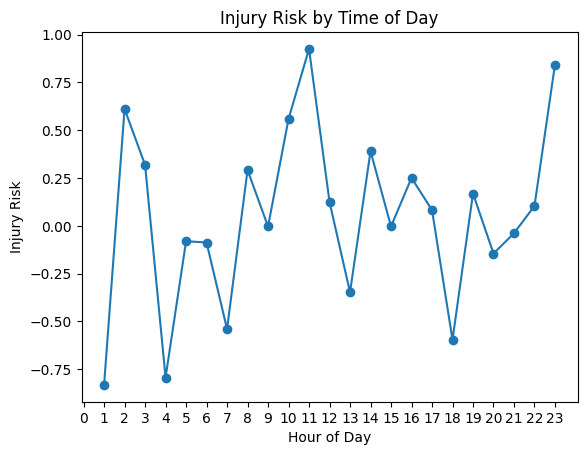

In [ ]:
# plot the risk of injury by hour
plt.plot(hour_df['hour'], hour_df['coef'], marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Injury Risk")
plt.title("Injury Risk by Time of Day")
plt.xticks(range(0, 24))

In [ ]:
# examine day of week and coefs
day_df

,feature,coef
82,onehotencoder__DAY_OF_WEEK_1,0.254902
87,onehotencoder__DAY_OF_WEEK_6,0.117587
83,onehotencoder__DAY_OF_WEEK_2,-0.149103
84,onehotencoder__DAY_OF_WEEK_3,-0.181129
85,onehotencoder__DAY_OF_WEEK_4,-0.464505
86,onehotencoder__DAY_OF_WEEK_5,-0.809328


In [ ]:
# create a separate column for day
day_df['day'] = day_df['feature'].str.extract(r'DAY_OF_WEEK_(\d+)').astype(int)
day_df.sort_values('day', inplace=True)

([<matplotlib.axis.XTick at 0x787332169be0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6')])

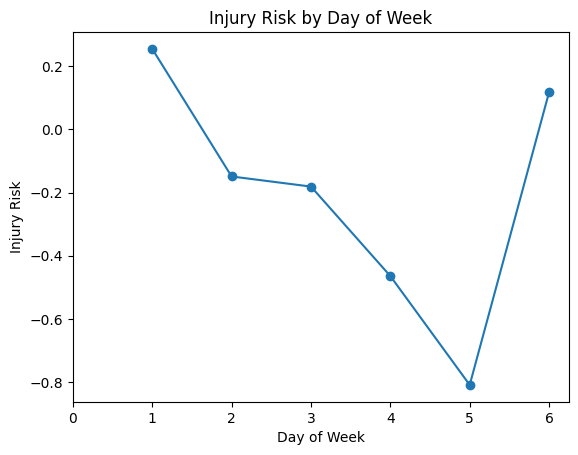

In [ ]:
# plot the risk of injury by day
plt.plot(day_df['day'], day_df['coef'], marker='o')
plt.xlabel("Day of Week")
plt.ylabel("Injury Risk")
plt.title("Injury Risk by Day of Week")
plt.xticks(range(0, 7))

In [ ]:
# check month coefs
month_df.head(5)

,feature,coef
79,onehotencoder__MONTH_9,0.593796
77,onehotencoder__MONTH_7,0.575180
73,onehotencoder__MONTH_3,0.456067
78,onehotencoder__MONTH_8,0.108727
74,onehotencoder__MONTH_4,0.076259


In [ ]:
# create a separate column for month
month_df['month'] = month_df['feature'].str.extract(r'MONTH_(\d+)').astype(int)
month_df.sort_values('month', inplace=True)

([<matplotlib.axis.XTick at 0x7873321ec740>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

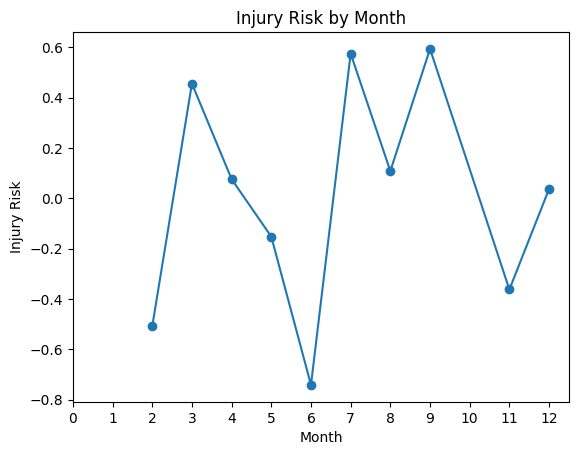

In [ ]:
# plot the risk of injury by month
plt.plot(month_df['month'], month_df['coef'], marker='o')
plt.xlabel("Month")
plt.ylabel("Injury Risk")
plt.title("Injury Risk by Month")
plt.xticks(range(0, 13))

In [ ]:
# separate borough dataframe
borough_df = coefs[coefs['feature'].str.contains('BOROUGH_')].copy().sort_values('coef', ascending=False)
borough_df['borough'] = borough_df['feature'].str.extract(r'BOROUGH_(\w+)').astype(str)

Text(0.5, 1.0, 'Injury Risk by Borough')

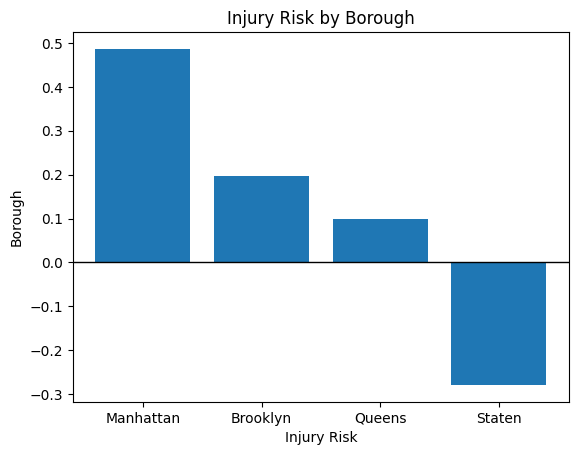

In [ ]:
plt.bar(borough_df['borough'], borough_df['coef'])
plt.axhline(0, color='black', linewidth=1) # x=0 line
plt.xlabel("Injury Risk")
plt.ylabel("Borough")
plt.title("Injury Risk by Borough")

The provided data reveals that injury risk is a highly volatile metric driven by geography, seasonality, and specific daily cycles. Manhattan is identified as the most hazardous borough, while temporal trends show that risk peaks dramatically during the start of the workweek on Mondays and Tuesdays and during the months of July and September. Within a 24-hour window, the highest danger levels occur at 11:00 AM and 11:00 PM, contrasting with the safest periods found in Staten Island, on Saturdays, and during the month of June. Furthermore, the safest hours of the day are consistently in the early morning between 1:00 AM and 4:00 AM, suggesting that risk is heavily concentrated during periods of high activity and geographic density.

In [ ]:
# params for grid searching
params = {'model__C': [0.01, 0.1, 1, 10, 100],
          'model__class_weight': [None, 'balanced'],
          'model__penalty': ['l1', 'l2']}

In [ ]:
# gridsearching & recall score
grid = GridSearchCV(pipe, params, scoring='recall')

In [ ]:
# fit
grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown ca

GridSearchCV(estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('pipeline',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['BOROUGH',
                                                                          'FACTORS',
                                                                          'VEHICLE_CODE']),
                                                                        ('onehotencoder',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['YEAR',
                                                                          'MONTH',
                                                                          'DAY_OF_WEEK',
                                                                          'HOUR'])])),
                                       ('model', LogisticRegression())]),
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__class_weight': [None, 'balanced'],
                         'model__penalty': ['l1', 'l2']},
             scoring='recall')

In [ ]:
# recall score
grid.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


0.5853658536585366

In [ ]:
# best params
grid.best_params_

{'model__C': 1, 'model__class_weight': 'balanced', 'model__penalty': 'l2'}

In [ ]:
# using the best params
best_model = grid.best_estimator_
y_pred_best_test = best_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Text(0.5, 1.0, 'Best Predictions')

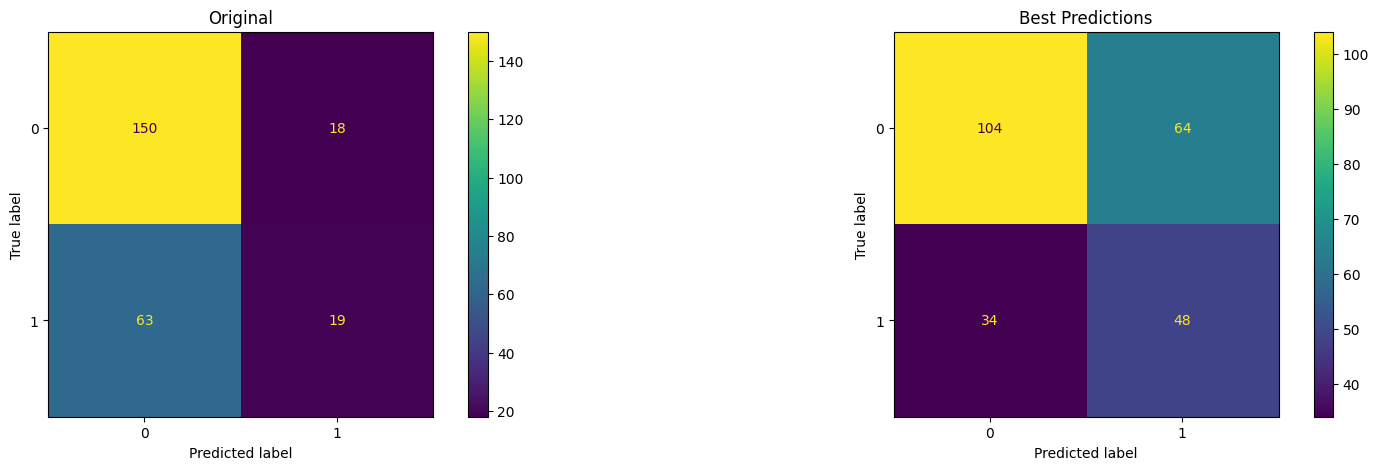

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (20, 5))

# original confusion matrix
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, ax=ax[0])
ax[0].set_title('Original')
# best predictions confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_test, ax=ax[1])
ax[1].set_title('Best Predictions')

The Best Predictions model is the more effective tool for injury prevention. It reduces the number of "missed" injuries from 63 to 35, making it a much more proactive model for identifying risk on New York City roads.

Next, we use a 0.30 probability threshold instead of 0.50 to prioritize recall and reduce false negatives, reflecting a cost-sensitive classification setting where missing positive cases is more undesirable than increasing false positives.

In [ ]:
# best predictions on whole set
y_pred_best = best_model.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Text(0.5, 1.0, 'Best Predictions')

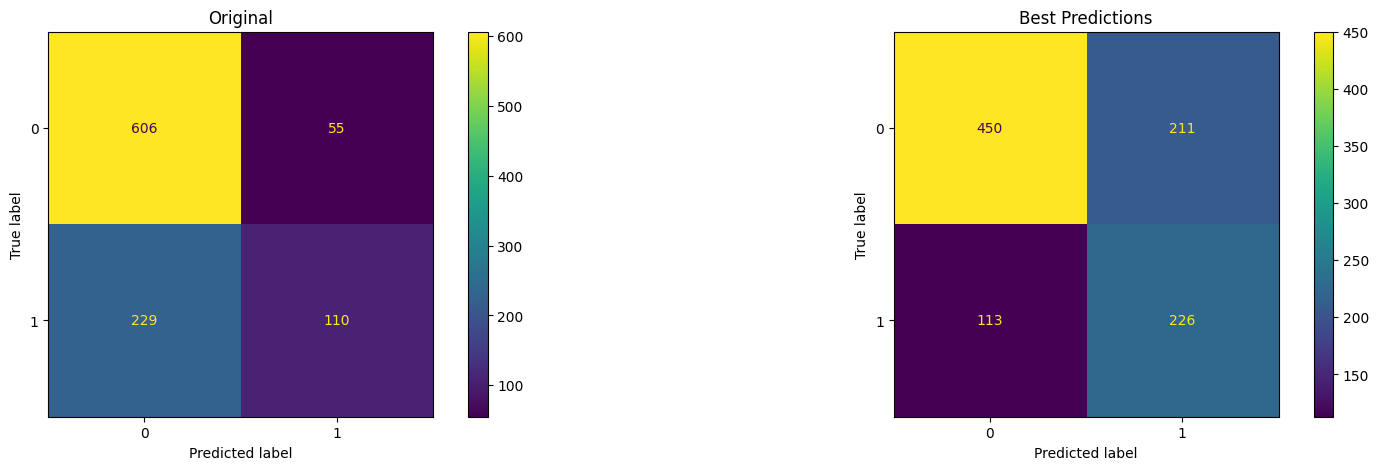

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (20, 5))

# original confusion matrix
ConfusionMatrixDisplay.from_estimator(pipe, X, y, ax=ax[0])
ax[0].set_title('Original')
# best predictions confusion matrix
ConfusionMatrixDisplay.from_predictions(y, y_pred_best, ax=ax[1])
ax[1].set_title('Best Predictions')

In [ ]:
#extracting probability of default from lgr
probability_default = pipe.predict_proba(X)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
#change the probability threshold to predict yes if greater than 30% probability
new_predictions = np.where(probability_default > .3, 1, 0)

Text(0.5, 1.0, 'Confusion Matrix of Injury Risk in 0.3 Probability')

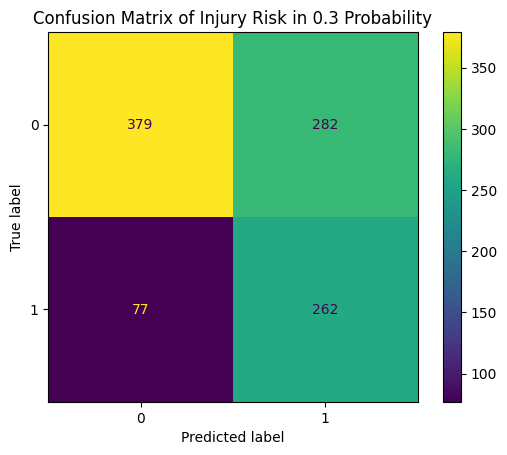

In [ ]:
# confusion matrix from predictions
ConfusionMatrixDisplay.from_predictions(y, new_predictions)
plt.title('Confusion Matrix of Injury Risk in 0.3 Probability')

Lowering the probability threshold significantly increased the number of injuries guessed correctly while that of non-injuries guessed correctly decreased.